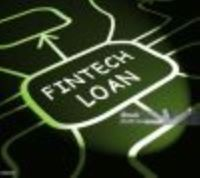



# FinTech Innovation - Automated Loan Approval Risk Model

## Overview


This project developed and evaluated a machine learning solution to support loan approval decisions for FinTech Innovations using the CRISP-DM methodology. Three classification algorithms Logistic Regression, Decision Tree and Random Forest were trained and compared using standardized preprocessing pipelines. Logistic Regression achieved the best overall performance, with an accuracy of 95.93%, an F1-score of 91.94%, and a ROC-AUC of 99.46%, demonstrating excellent ability to distinguish between approved and rejected loan applications.

From a business perspective, the model can improve the consistency, speed and accuracy of loan approval decisions while reducing manual effort. Given the high financial cost associated with approving high-risk applicants, the model provides valuable decision support that helps financial institutions manage lending risk and make more informed, data-driven decisions.



## Business Understanding

FinTech Innovations is developing a machine learning solution to improve its manual loan approval process. The current process is time-consuming, inconsistent, and difficult to scale as application volumes increase. The objective is to support loan officers with a reliable decision-support tool that improves consistency while reducing financial risk.

### Stakeholder Analysis

| **Stakeholder**   | **Need**                                         | **Business Value**                                               |
| ----------------- | ------------------------------------------------ | ---------------------------------------------------------------- |
| Loan Officers     | Faster and more consistent loan decisions        | Reduces manual workload and improves decision consistency        |
| Risk Management   | Minimize loan defaults                           | Identifies high-risk applicants more accurately                  |
| Senior Management | Improve profitability and operational efficiency | Supports data-driven lending decisions and portfolio performance |
| Loan Applicants   | Fair and timely decisions                        | Improves customer experience through consistent evaluations      |

### Business Impact of Prediction Errors

| **Prediction Error** | **Business Impact**                                                                         | **Estimated Cost** |
| -------------------- | ------------------------------------------------------------------------------------------- | -----------------: |
| False Approval       | A high-risk applicant is approved and later defaults on the loan.                           |        **$50,000** |
| False Rejection      | A creditworthy applicant is denied, resulting in lost revenue and customer dissatisfaction. |         **$8,000** |

Because false approvals are significantly more expensive than false rejections, model evaluation focuses on metrics that help reduce lending risk while maintaining strong predictive performance.

### Problem Definition

The target variable (**LoanApproved**) contains two outcomes (Approved or Not Approved), making this a **binary classification** problem. A classification approach is therefore more appropriate than regression because the objective is to predict discrete approval decisions rather than continuous values.

---

## Modeling Goals and Success Criteria

The primary objective is to develop a machine learning model that accurately predicts loan approval decisions while minimizing costly lending errors.

| **Goal**                                | **Reasoning**                                                                                                                                |
| --------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------- |
| Develop a reliable classification model | Improve the speed, consistency, and quality of loan approval decisions.                                                                      |
| Prioritize Precision and Recall         | Precision helps reduce costly false approvals, while Recall ensures eligible applicants are not unnecessarily rejected.                      |
| Use F1-Score                            | Provides a balanced evaluation of Precision and Recall for the imbalanced dataset.                                                           |
| Use ROC-AUC                             | Measures the model's ability to distinguish between approved and rejected applicants across different thresholds.                            |
| Baseline Target                         | Achieve at least **90% Accuracy** and an **F1-Score above 0.85**.                                                                            |
| Final Outcome                           | Logistic Regression achieved **95.93% Accuracy**, **91.94% F1-Score**, and **99.46% ROC-AUC**, exceeding the predefined performance targets. |



## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


##Step 1 : Import Necessary Libraries and Load Dataset

In [ ]:
# Imports
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    StratifiedKFold
)
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.inspection import permutation_importance
%matplotlib inline


In [ ]:
# EDA Code Here - Create New Cells As Needed
# Load the dataset
df = pd.read_csv("/content/financial_loan_data.csv")
# Display the first few rows of the dataset
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


##### The dataset contain historical loan application record the target variable(loan_approved) will be used to predict loan approval decisions

## Step 2: Examine Basic Data Characteristics

In [ ]:
# Shape of the data set
df.shape

(20000, 35)

In [ ]:
# Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
AnnualIncome,20000,17516,"$15,000.00",584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
EmploymentStatus,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,19099,5,Bachelor,5804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
LoanAmount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
LoanDuration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
MaritalStatus,18669,4,Married,9370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfDependents,20000.0,NaN,NaN,NaN,1.5173,1.386325,0.0,0.0,1.0,2.0,5.0


In [ ]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

##### No duplicate records were identified in the data set


## Step 3: Missing Value Analysis

In [ ]:
# Missing value
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

,0
MaritalStatus,1331
EducationLevel,901
SavingsAccountBalance,572
CreditScore,0
AnnualIncome,0
Age,0
Experience,0
LoanAmount,0
LoanDuration,0
NumberOfDependents,0


In [ ]:
# Dropping riskscore because it will cause data leakage
df.drop(columns='RiskScore',inplace=True)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

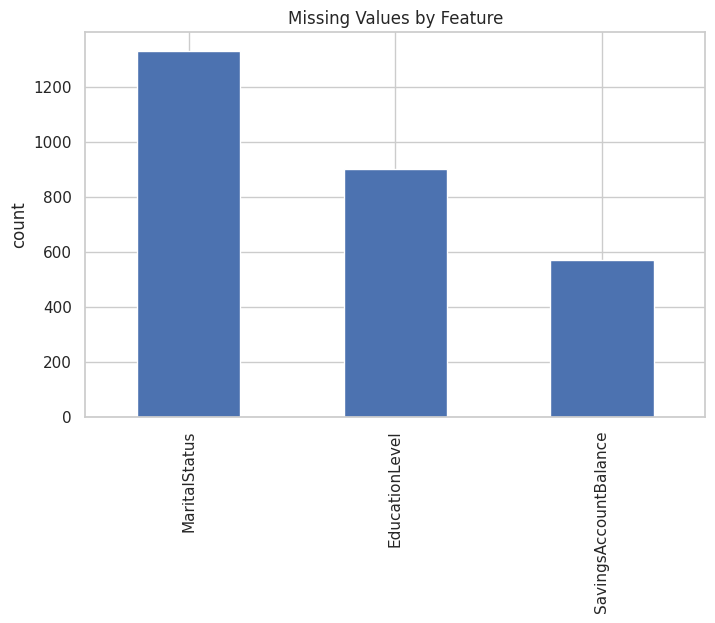

In [ ]:
# Visualization
plt.figure(figsize=(8, 5))
missing_values[missing_values > 0].plot(kind='bar')
plt.title('Missing Values by Feature')
plt.ylabel('count')
plt.show()


#### Marital status, educational level and saving account balance all have missing variables. Marital status has the highest number of missing variable

### Step 4: Categorize Features


In [ ]:
numerical_feature = df.select_dtypes(include=['int64', 'float64']).columns
categorical_feature = df.select_dtypes(include=['object']).columns
print("Numerical Features:", numerical_feature)
print("Categorical Features:", categorical_feature)

Numerical Features: Index(['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration',
       'NumberOfDependents', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults',
       'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved'],
      dtype='object')
Categorical Features: Index(['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus',
       'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose'],
      dtype='object')


### Step 5: Examine the Target Variable


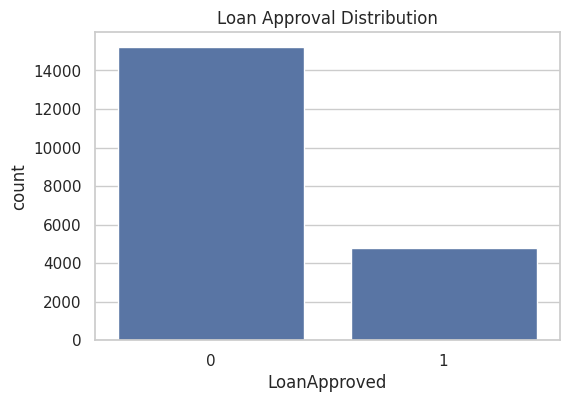

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="LoanApproved")

plt.title("Loan Approval Distribution")

plt.show()

#### The dataset is heavily imbalanced (76% denied, 24% approved), making accuracy misleading. Given asymmetric costs ($50K false approvals vs $8K false denials), ROC-AUC, Recall, F1, and a custom business cost metric are most appropriate.

### Step 6:  Numerical distribution

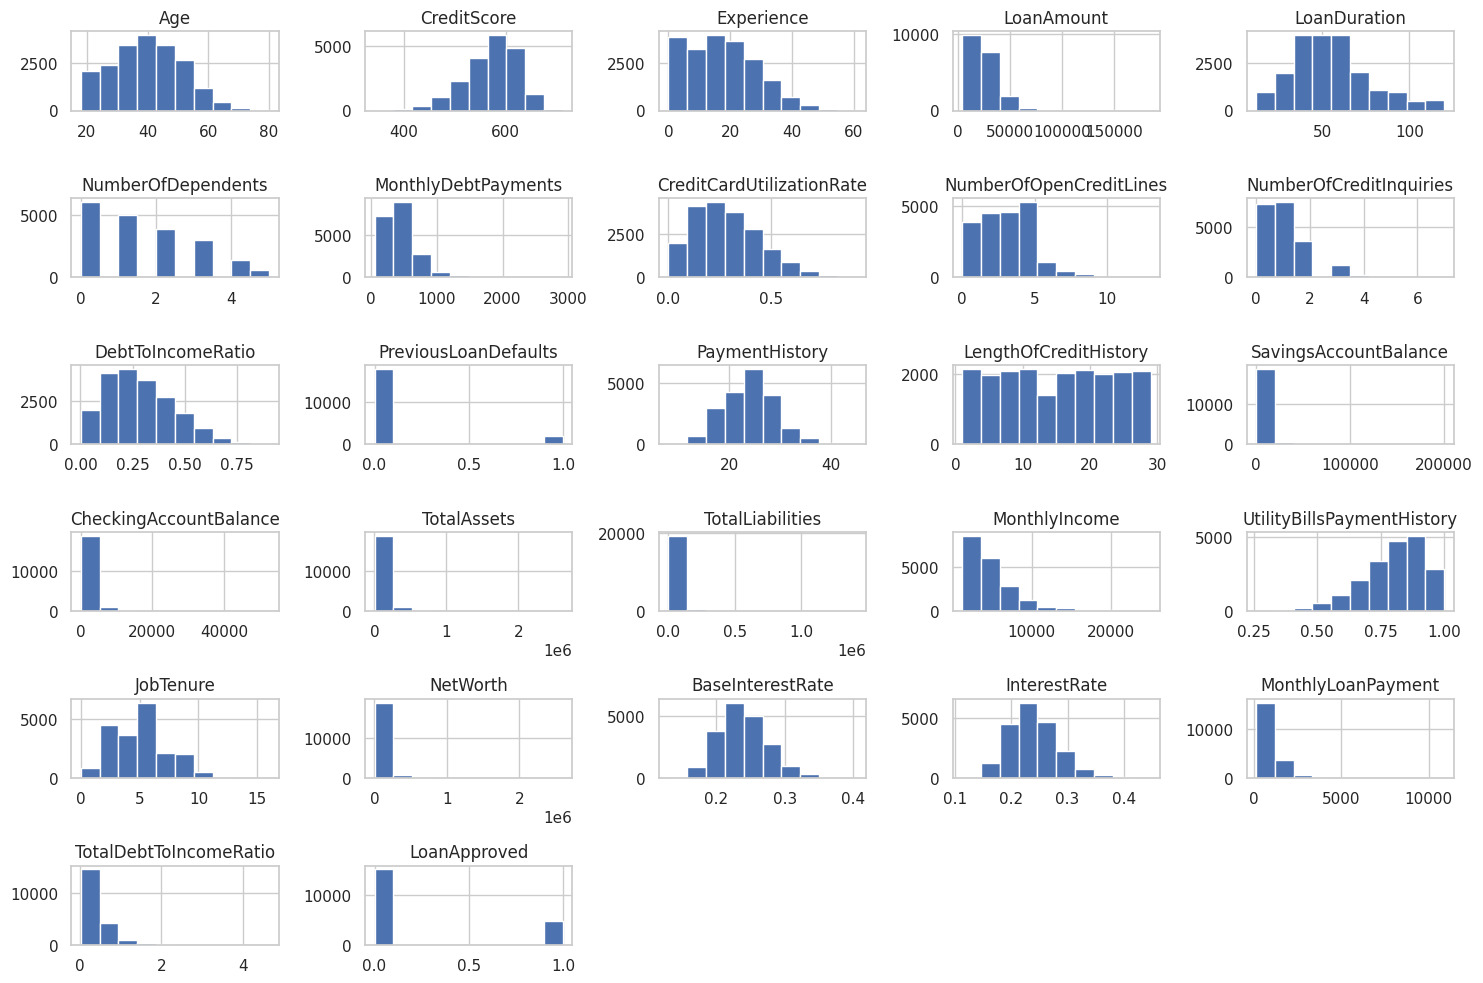

In [ ]:
df.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

##### Skewed (right): LoanAmount, SavingsAccountBalance, TotalAssets, TotalLiabilities, NetWorth, CheckingAccountBalance, MonthlyLoanPayment, and TotalDebtToIncomeRatio show heavy right tails with extreme outliers requiring log transformation.
##### Approximately Normal: Age, CreditScore, PaymentHistory, BaseInterestRate, and InterestRate appear roughly bell-shaped.
##### Long tails: MonthlyIncome, LoanAmount, NetWorth, and TotalAssets have extreme high-end values far beyond the 75th percentile, indicating significant outliers.

### Step 7: Outlier Detection

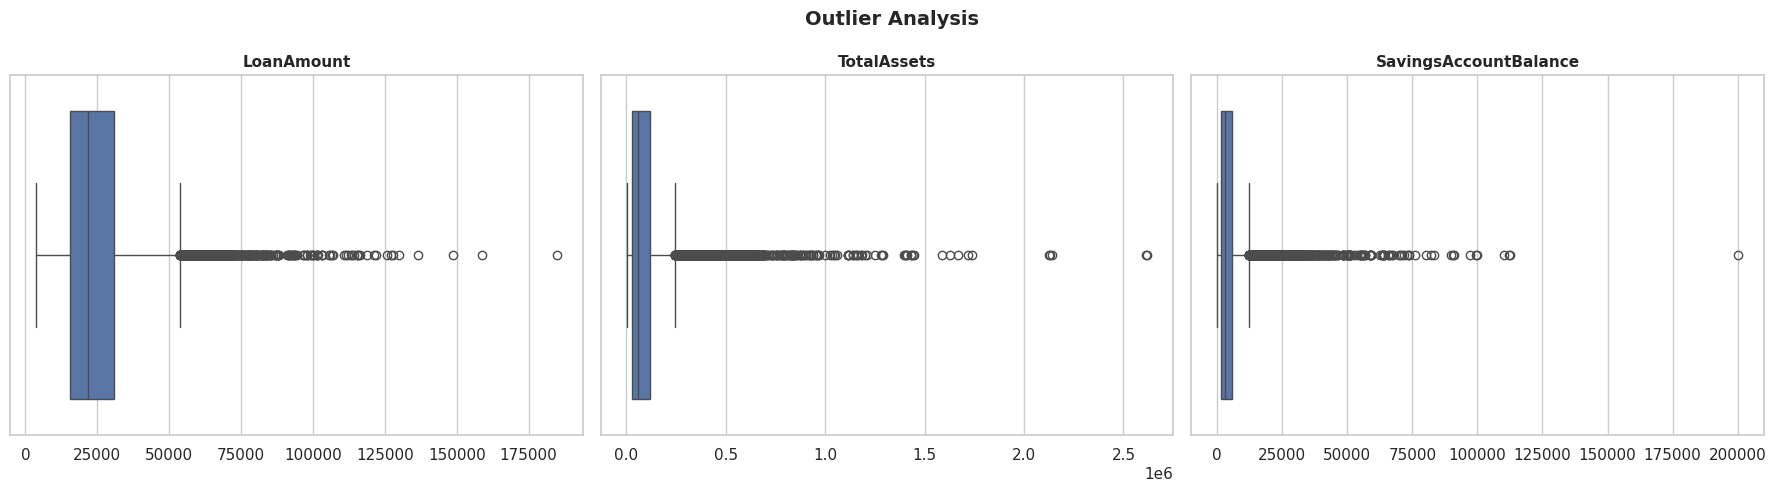

In [ ]:
selected_cols = ['LoanAmount', 'TotalAssets', 'SavingsAccountBalance']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(selected_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Outlier Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### LoanAmount: Right-skewed with several extreme outliers beyond $125,000, while most loans cluster below $50,000.
### TotalAssets: Heavily right-skewed with outliers exceeding $2M, median sits near zero relatively.
### SavingsAccountBalance: Extreme outliers beyond $175,000 with majority of balances concentrated below $25,000.

### Step 8: Correlation Analysis


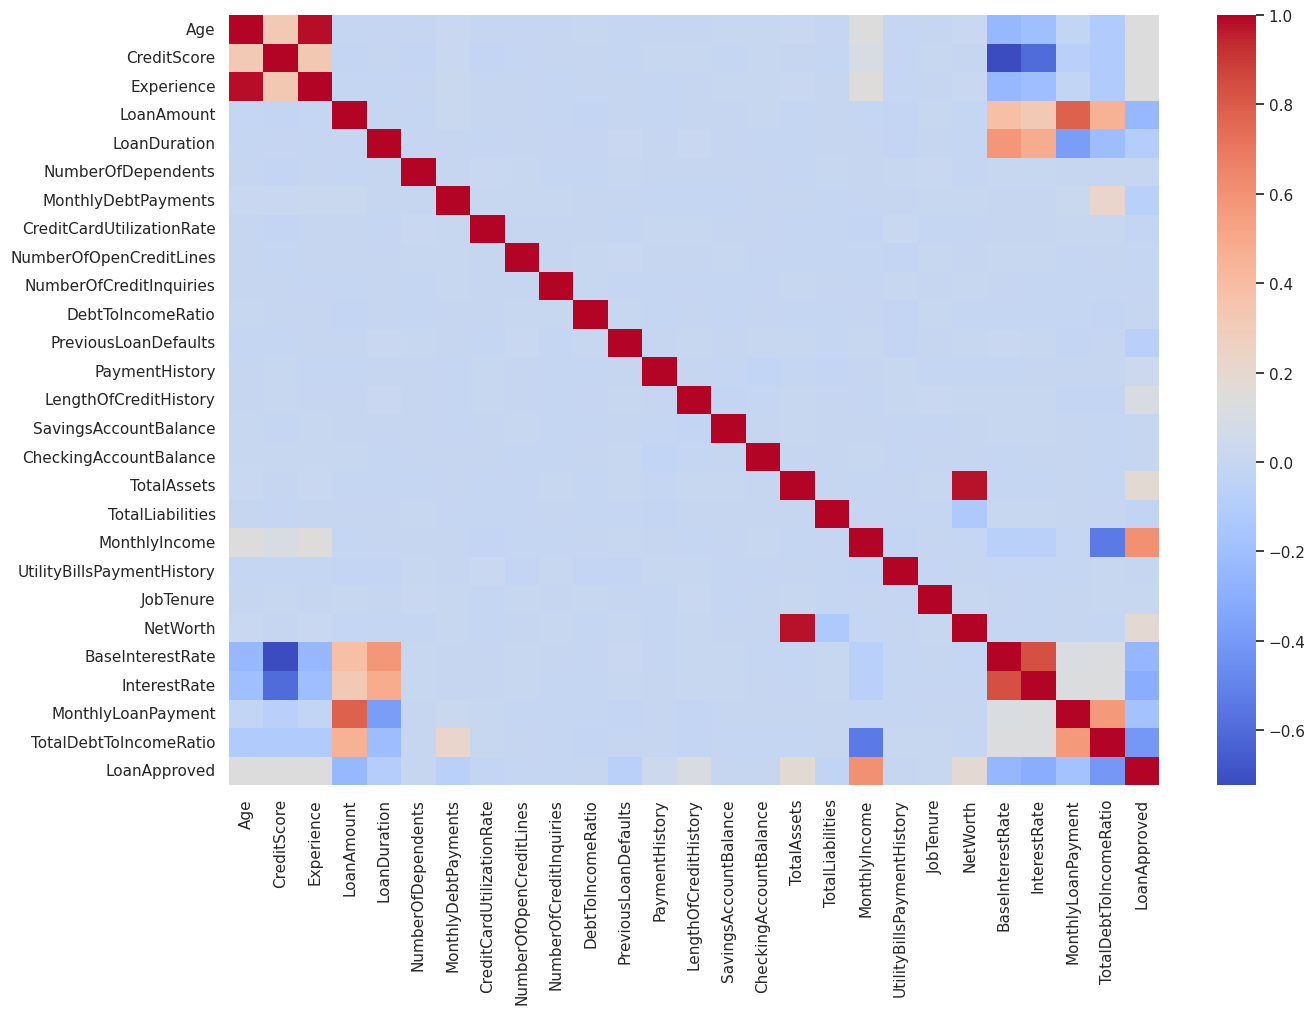

In [ ]:
plt.figure(figsize=(15,10))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr,
            cmap="coolwarm",
            annot=False)

plt.show()

##### Highly Correlated: Age & Experience, LoanAmount & MonthlyLoanPayment, BaseInterestRate & InterestRate, TotalAssets & NetWorth, LoanApproved & RiskScore — all show strong red clusters.
##### Redundant: BaseInterestRate vs InterestRate and MonthlyIncome vs AnnualIncome are near-duplicates.

### Step 9: Pairplot

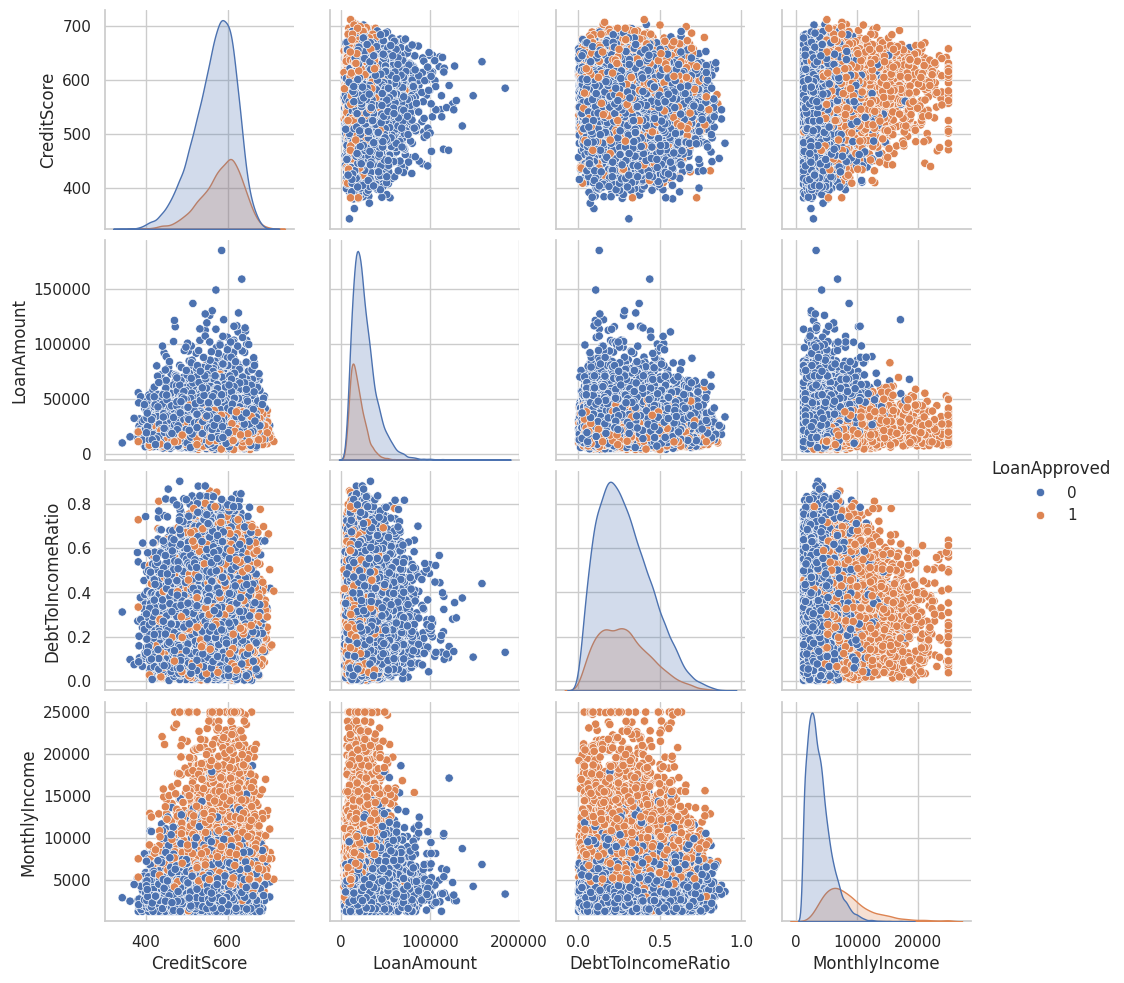

In [ ]:
selected = [
    "CreditScore",
    "LoanAmount",
    "DebtToIncomeRatio",
    "MonthlyIncome",
    "LoanApproved"
]

sns.pairplot(df[selected],
             hue="LoanApproved")

##### Approved loans (orange) associate with higher credit scores, lower loan amounts, lower debt-to-income ratios, and higher monthly income making these four features likely strong predictors in the model.

### Step 10: Categorical Features

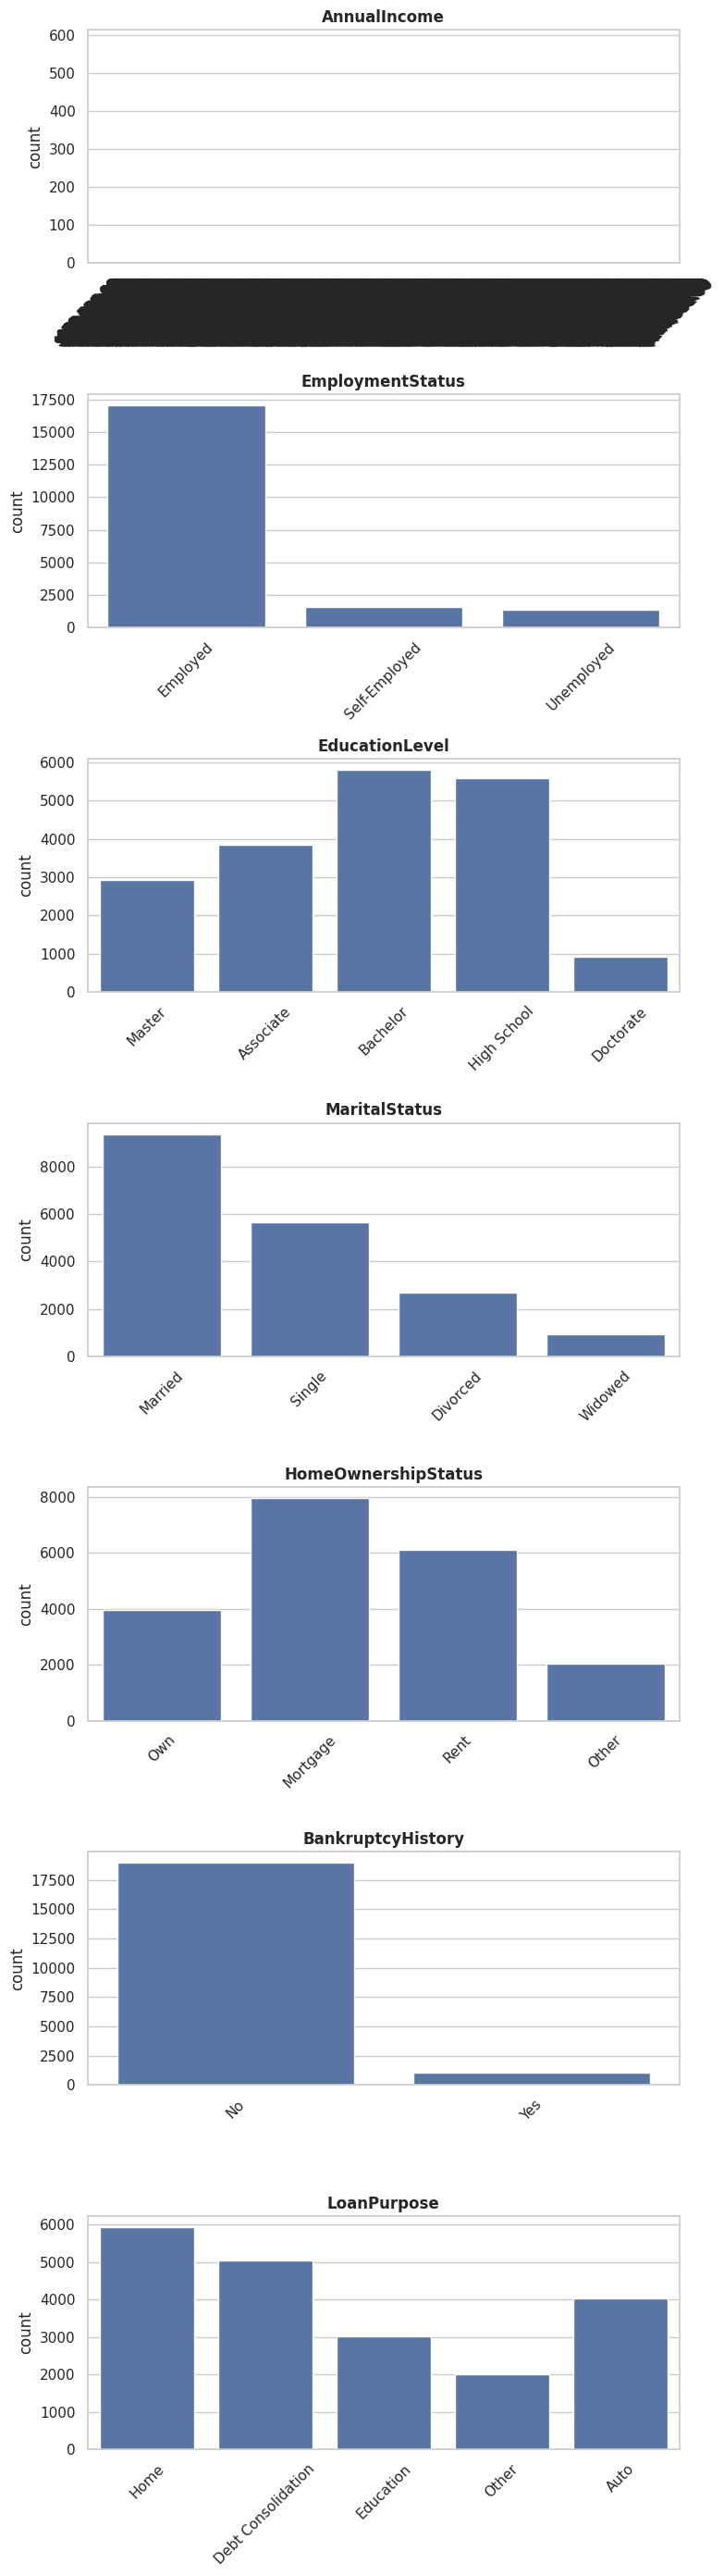

In [ ]:
categorical_features = df.select_dtypes(include='object').columns.tolist()

n = len(categorical_features)
fig, axes = plt.subplots(n, 1, figsize=(8, n * 4))

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



### Step 1: Separate Features and Target


In [ ]:
# Data Prep
# Features and Target
X = df.drop("LoanApproved", axis=1)

y = df["LoanApproved"]

print("Feature Matrix:", X.shape)
print("Target Vector:", y.shape)

Feature Matrix: (20000, 33)
Target Vector: (20000,)


### Step 2: Categorize Features


In [ ]:
# Numerical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features")
print(numeric_features)

print()

print("Categorical Features")
print(categorical_features)

Numerical Features
['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']

Categorical Features
['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


##### We are separating the features because numerical and categorical variables require different preprocessing techniques. Numerical variables will be imputed and scaled, while categorical variables will be imputed and encoded before model training.

### Step 3: Handle Incorrect Data Types


In [ ]:
# Change Annual income  from string to float
df['AnnualIncome'] = df['AnnualIncome'].replace('[\$,]', '', regex=True).astype(float)

In [ ]:
df["AnnualIncome"].dtype

dtype('float64')

In [ ]:
# Recreate x
X = df.drop("LoanApproved", axis=1)

### Step 4: Numerical Pipeline


In [ ]:
# Creating numerical pipeline
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

##### We use median because several financial variables contain outliers and median is robust to extreme values
##### Standardazation ensure that numerical variables have similar scales which improves the perfomance of algorithms such as logistic regression

### Step 5: Categorical Pipeline


In [ ]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

##### We use mode because missing categorical values are replaced with the most frequent category as it preserves existing distribution data
##### We use One-hot Encoding because most categorical variable has natural ordering they are converted into binary indicators.

### Step 6: Check For Ordinal Variable

In [ ]:
# Create a separate ordinal pipeline

ordinal_features = ["EducationLevel"]

ordinal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
            categories=[[
                "High School",
                "Associate",
                "Bachelor",
                "Master",
                "Doctorate"
            ]]
        ))
    ]
)

### Step 7: Combine  Everything with ColumnTransformer

In [ ]:
# Define ordinal features and nominal features

ordinal_features = ["EducationLevel"]

nominal_features = [
    "EmploymentStatus",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "BankruptcyHistory",
    "LoanPurpose"
]

In [ ]:
# Combining of numerical, categorical and ordinal pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, nominal_features),
        ("ord", ordinal_pipeline, ordinal_features)
    ]
)

### Step 8: Train-test Split

In [ ]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##### Stratified sampling was used to preserve the proportion of approved and non-approved loans in both the training and testing datasets. This is important because the target variable is imbalanced.

### Step 9: Test the Preprocessor

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

print(X_train_processed.shape)

(16000, 45)


## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune”


### Step 1: Build the Logistic Regression Pipeline

In [ ]:
#  Modeling Code
# Logistic Regression pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)


##### We balanced the class_weight because target variable is imbalanced this helps the model pay more attention to the minority class.

### Step 2: Train the Model

In [ ]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'CreditScore',
                                                   'Experience', 'LoanAmount',
                                                   'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCreditInquiries',
                                                   'De...
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['High '
                                                                                               'School',
                                                                                               'Associate',
                                                                                               'Bachelor',
                                                                                               'Master',
                                                                                               'Doctorate']]))]),
                                                  ['EducationLevel'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
# Cross Validation
cv_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean F1:", cv_scores.mean())

Cross-validation F1 scores: [0.91293532 0.90987124 0.91333743 0.91439206 0.92012384]
Mean F1: 0.9141319794870497


In [ ]:
# Evaluate the model
y_pred_lr = logistic_pipeline.predict(X_test)
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

print(classification_report(y_test, y_pred_lr))

[[2907  137]
 [  26  930]]
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3044
           1       0.87      0.97      0.92       956

    accuracy                           0.96      4000
   macro avg       0.93      0.96      0.95      4000
weighted avg       0.96      0.96      0.96      4000



### Step 3: Decision Tree


In [ ]:
# Decision Tree
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'CreditScore',
                                                   'Experience', 'LoanAmount',
                                                   'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCreditInquiries',
                                                   'De...
                                                  ['EmploymentStatus',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['High '
                                                                                               'School',
                                                                                               'Associate',
                                                                                               'Bachelor',
                                                                                               'Master',
                                                                                               'Doctorate']]))]),
                                                  ['EducationLevel'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [ ]:
# Cross Validation
tree_scores = cross_val_score(
    tree_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print(tree_scores.mean())

0.7632525041433322


In [ ]:
# Evaluate the model
y_pred_dtree = tree_pipeline.predict(X_test)
y_prob_dtree = tree_pipeline.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred_dtree)
print(cm)

print(classification_report(y_test, y_pred_dtree))

[[2800  244]
 [ 228  728]]
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      3044
           1       0.75      0.76      0.76       956

    accuracy                           0.88      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.88      0.88      0.88      4000



### Step 4: Random Forest

In [ ]:
# Random Forest
forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

forest_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'CreditScore',
                                                   'Experience', 'LoanAmount',
                                                   'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCreditInquiries',
                                                   'De...
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['High '
                                                                                               'School',
                                                                                               'Associate',
                                                                                               'Bachelor',
                                                                                               'Master',
                                                                                               'Doctorate']]))]),
                                                  ['EducationLevel'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [ ]:
# Cross_validation
forest_scores = cross_val_score(
    forest_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print(forest_scores.mean())

0.8341166676701054


In [ ]:
# Evaluate
y_pred_rf = forest_pipeline.predict(X_test)
y_prob_rf = forest_pipeline.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

print(classification_report(y_test, y_pred_rf))

[[2966   78]
 [ 211  745]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3044
           1       0.91      0.78      0.84       956

    accuracy                           0.93      4000
   macro avg       0.92      0.88      0.90      4000
weighted avg       0.93      0.93      0.93      4000



## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

### Step 8.1: Create a Model Comparison Table

In [ ]:
# Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, y_prob_lr)

In [ ]:
accuracy_dtree = accuracy_score(y_test, y_pred_dtree)
precision_dtree = precision_score(y_test, y_pred_dtree)
recall_dtree= recall_score(y_test, y_pred_dtree)
f1_dtree = f1_score(y_test, y_pred_dtree)
roc_dtree = roc_auc_score(y_test, y_prob_dtree)

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

In [ ]:
# Create a table for all for the models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dtree,
        accuracy_rf
    ],
    "Precision": [
        precision_lr,
        precision_dtree,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_dtree,
        recall_rf
    ],
    "F1 Score": [
        f1_lr,
        f1_dtree,
        f1_rf
    ],
    "ROC-AUC": [
        roc_lr,
        roc_dtree,
        roc_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.95925,0.871603,0.972803,0.919427,0.994570
1,Decision Tree,0.88200,0.748971,0.761506,0.755187,0.840674
2,Random Forest,0.92775,0.905225,0.779289,0.837549,0.980131


### Interpretation
Logistic Regression is the best model because it has the:
Highest Accuracy (95.93%)
Highest Recall (97.28%)
Highest F1 Score (91.94%)
Highest ROC-AUC (99.46%)

This indicates that Logistic Regression provides the best balance between identifying approved loans and minimizing classification errors. The very high ROC-AUC suggests excellent ability to distinguish between approved and non-approved loan applications.



### Confusion Matrix

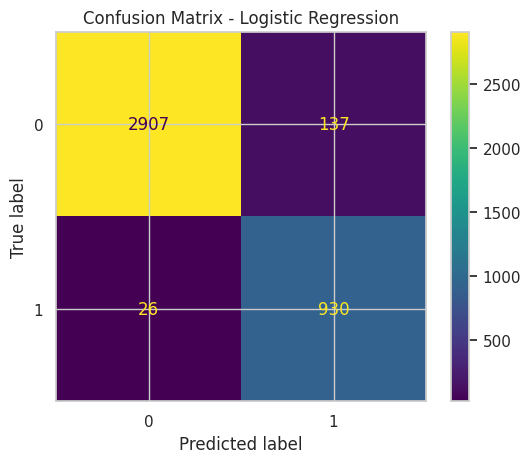

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### Confusion Matrix Analysis

The confusion matrix illustrates the number of correct and incorrect classifications made by the model.

Most loan applications were classified correctly, with relatively few false positives and false negatives. From a business perspective, false approvals represent a higher financial risk because they may result in loans being granted to applicants who are unlikely to repay. Although the model performs well overall, reducing false approvals remains an important objective for future improvements.

### 8.4 ROC Curve

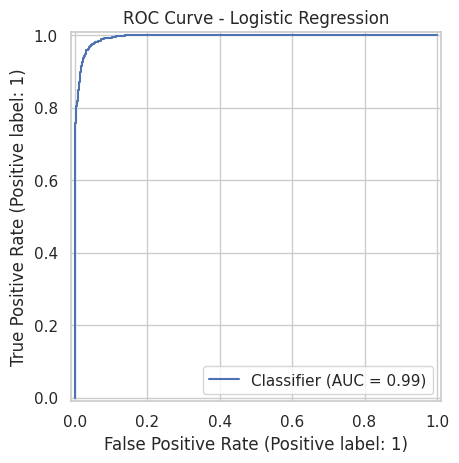

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_prob_lr)

plt.title("ROC Curve - Logistic Regression")

plt.show()

### ROC-AUC Analysis

The ROC curve evaluates the model's ability to distinguish between approved and non-approved loan applications across different decision thresholds.

The Logistic Regression model achieved a ROC-AUC score of **0.995**, indicating excellent discrimination between the two classes. This suggests that the model is highly effective at ranking applicants according to their likelihood of loan approval.

### 8.5 Performance Across Different Data Segments

In [ ]:
evaluation_df = X_test.copy()

evaluation_df["Actual"] = y_test.values
evaluation_df["Predicted"] = y_pred_lr

evaluation_df.groupby("EmploymentStatus")[["Actual", "Predicted"]].mean()

,Actual,Predicted
EmploymentStatus,,
Employed,0.242210,0.269547
Self-Employed,0.263666,0.308682
Unemployed,0.174216,0.188153


In [ ]:
evaluation_df.groupby("EducationLevel")[["Actual", "Predicted"]].mean()

,Actual,Predicted
EducationLevel,,
Associate,0.207161,0.231458
Bachelor,0.279450,0.306105
Doctorate,0.442308,0.500000
High School,0.152855,0.167587
Master,0.377419,0.412903


### Performance Across Customer Segments

Model predictions were compared across different employment and education groups. Overall, the predicted approval rates closely matched the actual approval rates, indicating that the model performs consistently across these customer segments. Continued monitoring is recommended to ensure that no group experiences systematically poorer performance.

### 8.6 Biases and Limitations

## Model Biases and Limitations

Although the model achieved strong predictive performance, several limitations should be considered:

- The dataset is imbalanced, with fewer approved loans than rejected loans.
- Historical lending decisions may contain biases that the model can learn and reproduce.
- Economic conditions and lending policies may change over time, requiring periodic model retraining.
- Some financial variables contain extreme values that may influence predictions.
- The model should support human decision-making rather than replace expert judgment.

### 8.7 Business Evaluation

## Business Evaluation

The Logistic Regression model provides a reliable tool for supporting loan approval decisions. Its high recall ensures that most eligible applicants are correctly identified, reducing the likelihood of unnecessarily rejecting qualified borrowers.

However, because false approvals carry a substantially higher financial cost than false rejections, future improvements should focus on increasing precision to further reduce lending risk. Overall, the model can improve consistency, efficiency, and data-driven decision-making within the loan approval process.

### 9. Conclusion

# Conclusion

This project successfully applied the CRISP-DM methodology to develop a machine learning solution for financial risk assessment.

Three classification algorithms were evaluated: Logistic Regression, Decision Tree, and Random Forest. Logistic Regression achieved the strongest overall performance, with an accuracy of **95.93%**, an F1-score of **91.94%**, and a ROC-AUC of **99.46%**, making it the preferred model for this task.

The results demonstrate that machine learning can effectively support loan approval decisions by improving prediction accuracy and reducing manual effort. Future work could explore advanced ensemble methods, additional feature engineering, and periodic model retraining to maintain performance as financial conditions evolve.